# sfig11 — Task Similarity Clustermap (Supplementary Fig. S-11)

Hierarchical clustermap of AUROC at each context length across all tasks.
Rows = tasks (clustered by saturation curve shape); columns = context lengths.

**Data**: `analysis.csv`, k=all, Transformer head.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path

# ── Workspace root ────────────────────────────────────────────────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
PAPER_FIGURES  = NSRR_TOOLS / "results" / "paper_figures"
FINAL_OUT      = PAPER_FIGURES / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)

# Main utils (TBME style, data, panels)
_nb_dir = PAPER_FIGURES / "notebooks"
sys.path.insert(0, str(_nb_dir))
# Explore utils (panel functions not yet ported to main panels.py)
_explore_nb_dir = PAPER_FIGURES / "explore" / "notebooks"
sys.path.insert(0, str(_explore_nb_dir))

from utils.style import (
    apply_tbme_style, save_figure, FULL_W, HALF_W,
    MAIN_TASKS, SUPP_TASKS, ALL_TASKS,
    TASK_LABEL, FONT_BASE, FONT_LABEL, CTX_ORDER,
)
from utils.data import set_root, load_analysis, load_heatmap, load_parquets
from utils import panels
from utils import panels_explore as xp   # panel functions not yet in panels.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

set_root(WORKSPACE_ROOT)
apply_tbme_style()

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND — edit _find_workspace() fallback'}")

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS = MAIN_TASKS #+ ["depression_extreme_binary", "osa_binary_apples_postqc"]
HEAD  = "transformer"

df = load_analysis("phase0_v3", split="test", k="all")
print("Tasks in analysis.csv:", sorted(df["task"].unique()))

Tasks in analysis.csv: ['age_class', 'apnea_binary', 'bmi_binary', 'depression_extreme_binary', 'osa_binary_apples_postqc', 'sex_binary', 'sleep_efficiency_binary']


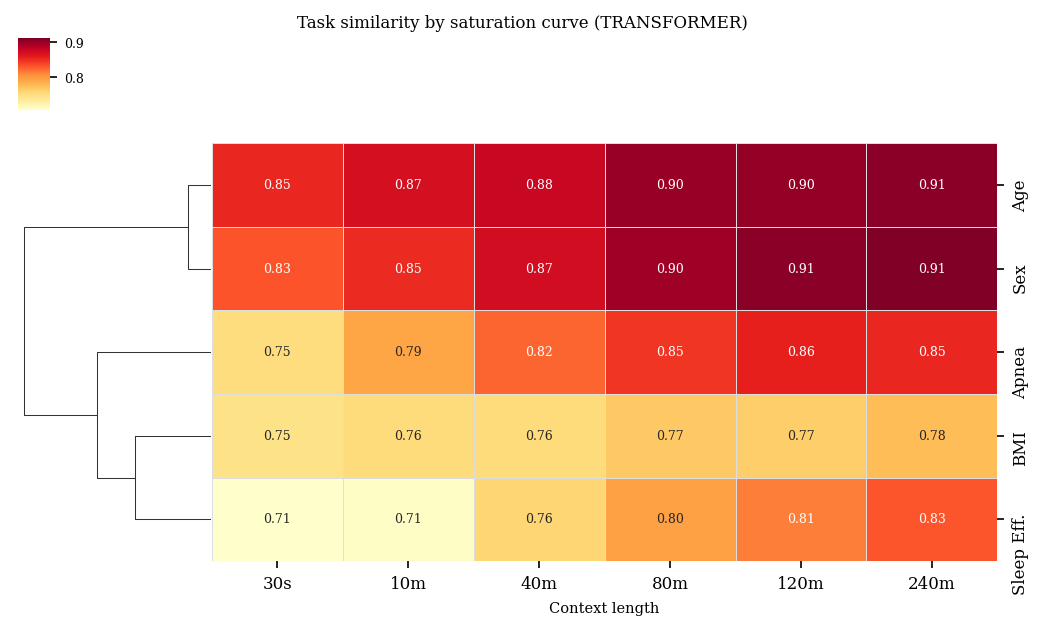

In [4]:
g = xp.task_clustermap(
    df,
    tasks=TASKS,
    head=HEAD,
    figsize=(7.0, 4.0),
)
plt.show()

In [ ]:
# ── Run when figure looks good ────────────────────────────────────────────────
save_figure(g.fig, FINAL_OUT, "sfig11_task_clustermap")
import shutil
shutil.copy(FINAL_OUT / "sfig11_task_clustermap.pdf",
            WORKSPACE_ROOT / "TBME_submission" / "sfig11_task_clustermap.pdf")
print("Saved + copied → TBME_submission/sfig11_task_clustermap.pdf")